In this notebook, we compare our previous best loss function (Proxy Anchor Loss) with a combined loss from Proxy Anchor Loss and Center loss.

## 1. Setup and Configuration

In [ ]:
EXPERIMENT_NAME = "loss_combined"
RANDOM_SEED = 51

import os

os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

from pathlib import Path
import sys

PROJECT_PATH = Path.cwd().parent
sys.path.insert(0, str(PROJECT_PATH))

from dotenv import load_dotenv
import math

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
from PIL import Image
from tabulate import tabulate
import wandb
import pandas as pd
import matplotlib.pyplot as plt
import timm
from timm.data import resolve_data_config
from timm.data.transforms_factory import create_transform
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from src.utils import (
    get_device,
    set_seeds,
    create_deterministic_training_dataloader,
)
from src.visualization import visualize_embeddings_mds

set_seeds(RANDOM_SEED)

print(f"PyTorch version: {torch.__version__}")

All random seeds set to 51 for reproducibility
PyTorch version: 2.9.1+cu128


In [85]:
# Define paths
DATA_PATH = PROJECT_PATH / "data"
OUTPUT_PATH = PROJECT_PATH / "output" / EXPERIMENT_NAME
OUTPUT_PATH_SHARED = PROJECT_PATH / "output" / "shared"
CHECKPOINT_PATH = PROJECT_PATH / "checkpoints" / EXPERIMENT_NAME
EMBEDDINGS_PATH = CHECKPOINT_PATH / "embeddings"

DATA_PATH.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH_SHARED.mkdir(parents=True, exist_ok=True)
CHECKPOINT_PATH.mkdir(parents=True, exist_ok=True)
EMBEDDINGS_PATH.mkdir(parents=True, exist_ok=True)

# Load environment variables from .env file
load_dotenv(dotenv_path=PROJECT_PATH / ".env")

True

In [ ]:
# Configuration
config = {       
    # Dinov3 Model
    "dinov3_model": "hf-hub:timm/vit_base_patch16_dinov3.lvd1689m",
    "dinov3_input_size": 224,

    # Model
    "embedding_dim": 256,
    "hidden_dim": 512,
    "dropout": 0.3,
    
    # ProxyAnchor
    "proxyanchor_margin": 0.1,
    "proxyanchor_alpha": 32.0,
    
    # Combined Loss
    "combined_lambda": 0.5,

    # Training
    "batch_size": 32,
    "learning_rate": 1e-4,
    "weight_decay": 1e-4,
    "num_epochs": 200,
    "patience": 10,
    "val_split": 0.2,
    
    # Reproducibility
    "seed": RANDOM_SEED,
}

print("Configuration:")
for key, value in config.items():
    print(f"  {key}: {value}")

Configuration:
  dinov3_model: hf-hub:timm/vit_base_patch16_dinov3.lvd1689m
  dinov3_input_size: 224
  embedding_dim: 256
  hidden_dim: 512
  dropout: 0.3
  arcface_margin: 0.5
  arcface_scale: 64.0
  cosface_margin: 0.35
  cosface_scale: 30.0
  sphereface_margin: 4
  sphereface_scale: 64.0
  proxyanchor_margin: 0.1
  proxyanchor_alpha: 32.0
  subcenter_arcface_margin: 0.5
  subcenter_arcface_scale: 64.0
  subcenter_arcface_num_subcenters: 3
  batch_hard_triplet_margin: 0.3
  batch_size: 32
  learning_rate: 0.0001
  weight_decay: 0.0001
  num_epochs: 200
  patience: 10
  val_split: 0.2
  seed: 51


In [87]:
# Initialize Weights and Biases for experiment tracking
# Key hyperparameters are tracked explicitly for easy filtering in W&B dashboard
if not os.getenv("WANDB_API_KEY"):
    print("Warning: WANDB_API_KEY not found in environment variables. W&B logging will be disabled.")
else:
    wandb.login()

    wandb.init(
        project="jaguar-reidentification",
        config=config,
        name=EXPERIMENT_NAME,
    )

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


best_epoch_arcface,▁
best_epoch_batch_hard_triplet,▁
best_epoch_center_loss,▁
best_epoch_cosface,▁
best_epoch_proxyanchor,▁
best_epoch_sphereface,▁
best_epoch_subcenterarcface,▁
epoch,▂▄▄▄▄▅▅▆▆▁▃▄▄▁▂▁▂▄▅▅▇█▃▅▅▁▂▂▄▄▆▇█▁▂▃▃▄▅▇
final_val_mAP_arcface,▁
final_val_mAP_batch_hard_triplet,▁
+19,...


## Data Loading

In [88]:
# Load training data
train_df = pd.read_csv(DATA_PATH / "train.csv").set_index("filename")

print(f"Training dataset:")
print(f"  Total images: {len(train_df)}")
print(f"  Unique identities: {train_df['ground_truth'].nunique()}")
print(f"\nSample rows:")
print(train_df.head())

Training dataset:
  Total images: 1895
  Unique identities: 31

Sample rows:
               ground_truth
filename                   
train_0001.png        Abril
train_0002.png        Abril
train_0003.png        Abril
train_0004.png       Akaloi
train_0005.png       Akaloi


Dataset split:
  Training:   1516 images (80%)
  Validation: 379 images (20%)

Identity coverage:
  Identities in training:   31
  Identities in validation: 31
  Overlap: 31
  All identities present in both sets


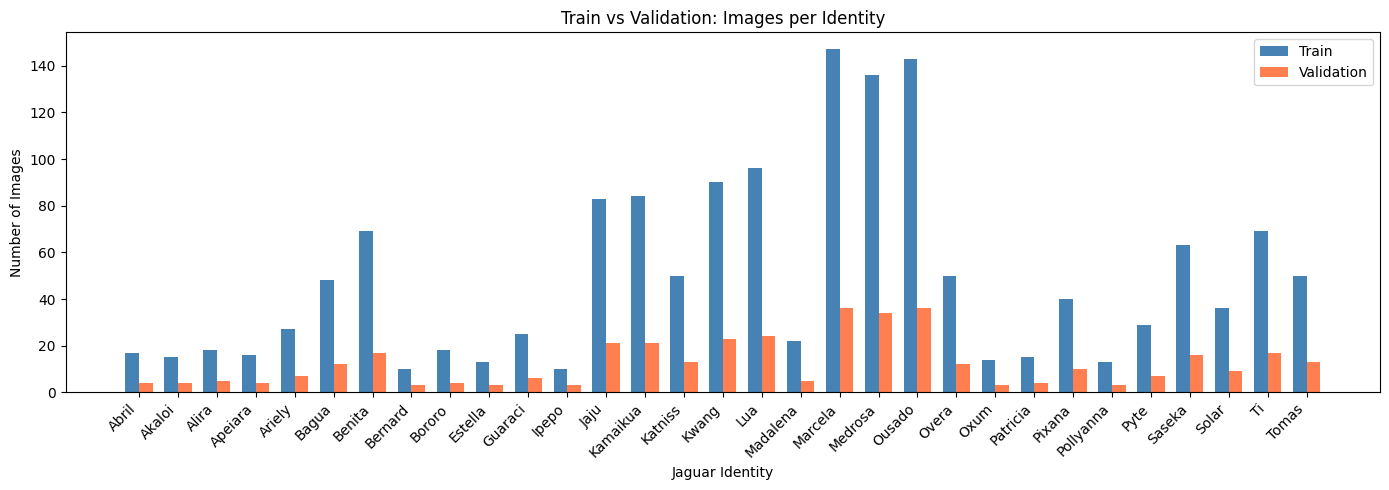


Logged identity distributions to W&B
  Train samples per identity: 10 - 147 (mean: 48.9)
  Val samples per identity: 3 - 36 (mean: 12.2)


In [89]:
# Create stratified train/validation split
# This ensures all identities appear in both sets

# Encode labels to integers
label_encoder = LabelEncoder()
train_df['label_encoded'] = label_encoder.fit_transform(train_df['ground_truth'])
num_classes = len(label_encoder.classes_)

# Stratified split: each identity's images are split proportionally
train_data, val_data = train_test_split(
    train_df,
    test_size=config["val_split"],
    random_state=config["seed"],
    stratify=train_df['ground_truth']  # Ensures proportional representation
)

print(f"Dataset split:")
print(f"  Training:   {len(train_data)} images ({100*(1-config['val_split']):.0f}%)")
print(f"  Validation: {len(val_data)} images ({100*config['val_split']:.0f}%)")

# Verify all identities are in both sets
train_identities = set(train_data['ground_truth'].unique())
val_identities = set(val_data['ground_truth'].unique())

print(f"\nIdentity coverage:")
print(f"  Identities in training:   {len(train_identities)}")
print(f"  Identities in validation: {len(val_identities)}")
print(f"  Overlap: {len(train_identities & val_identities)}")

if train_identities == val_identities:
    print("  All identities present in both sets")

# Log identity distributions to W&B
train_counts = train_data['ground_truth'].value_counts().sort_index()
val_counts = val_data['ground_truth'].value_counts().sort_index()

# Create a comparison table for W&B
distribution_df = pd.DataFrame({
    'identity': train_counts.index,
    'train_count': train_counts.values,
    'val_count': val_counts.values,
    'total_count': train_counts.values + val_counts.values,
    'train_ratio': train_counts.values / (train_counts.values + val_counts.values)
})

# Log table and summary stats to W&B
wandb.log({
    "identity_distribution_table": wandb.Table(dataframe=distribution_df),
    "num_identities": num_classes,
    "train_samples": len(train_data),
    "val_samples": len(val_data),
    "train_samples_per_identity": wandb.Histogram(train_counts.values),
    "val_samples_per_identity": wandb.Histogram(val_counts.values),
})

# Visualize train vs val distribution
fig, ax = plt.subplots(figsize=(14, 5))
width = 0.35
x = np.arange(len(train_counts))
ax.bar(x - width/2, train_counts.values, width, label='Train', color='steelblue')
ax.bar(x + width/2, val_counts.values, width, label='Validation', color='coral')
ax.set_xlabel('Jaguar Identity')
ax.set_ylabel('Number of Images')
ax.set_title('Train vs Validation: Images per Identity')
ax.set_xticks(x)
ax.set_xticklabels(train_counts.index, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
wandb.log({"train_val_distribution": wandb.Image(fig)})
plt.show()

print(f"\nLogged identity distributions to W&B")
print(f"  Train samples per identity: {train_counts.min()} - {train_counts.max()} (mean: {train_counts.mean():.1f})")
print(f"  Val samples per identity: {val_counts.min()} - {val_counts.max()} (mean: {val_counts.mean():.1f})")

## Training Utils

In [90]:
device = get_device()
print(f"Using device: {device}")

Using CUDA GPU
Using device: cuda


In [91]:
filenames = train_df.index.astype(str)
train_mask = filenames.isin(train_data.index.astype(str))

filenames = filenames.to_numpy()
labels = train_df["label_encoded"].to_numpy()
image_paths = [DATA_PATH / "train" / fn for fn in filenames]

In [92]:
@torch.no_grad()
def extract_embeddings(model, data_loader, desc="Extracting embeddings"):
    """Extract embeddings for a batch of images."""
    model.eval()
    embeddings = []

    for batch in tqdm(data_loader, desc=desc):
        batch = batch.to(device)
        with torch.no_grad():
            emb = model(batch)
        embeddings.append(emb.cpu().numpy())

    return np.concatenate(embeddings, axis=0)

print("Embedding extraction function defined")

Embedding extraction function defined


In [93]:
# Extract baseline embeddings for training data

def _load_cached_embeddings(cache_path, expected_filenames):
    z = np.load(cache_path, allow_pickle=True)
    cached_embeddings = z["embeddings"]
    cached_filenames = z["filenames"].tolist() if isinstance(z["filenames"], np.ndarray) else list(z["filenames"])

    if len(cached_filenames) != len(expected_filenames):
        return None

    if set(cached_filenames) != set(expected_filenames):
        return None

    idx = {fn: i for i, fn in enumerate(cached_filenames)}
    return np.stack([cached_embeddings[idx[fn]] for fn in expected_filenames], axis=0)

def get_embeddings(model, cache_path, data_loader):
    embeddings = None
    if cache_path.exists():
        embeddings = _load_cached_embeddings(cache_path, filenames)
        if embeddings is not None:
            print(f"Loaded cached embeddings from {cache_path}")
            print(f"Embeddings shape: {embeddings.shape}")
            
    if embeddings is None:
        print(f"Extracting embeddings for {len(data_loader)} images...")
        embeddings = extract_embeddings(
            model,
            data_loader
        )
        np.savez_compressed(
            cache_path,
            embeddings=embeddings,
            filenames=np.array(filenames, dtype=object),
        )
        print(f"Saved embeddings cache to {cache_path}")
        print(f"Embeddings shape: {embeddings.shape}")
        
    return embeddings


In [94]:
train_labels = train_data.loc[filenames[train_mask], "label_encoded"].values
val_labels = val_data.loc[filenames[~train_mask], "label_encoded"].values

In [95]:
class EmbeddingProjection(nn.Module):
    """
    Projects embeddings to a lower-dimensional space.
    Architecture: input_dim -> hidden_dim -> output_dim
    """
    
    def __init__(self, input_dim=1536, hidden_dim=512, output_dim=256, dropout=0.3):
        super().__init__()
        
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            
            nn.Linear(hidden_dim, output_dim),
            nn.BatchNorm1d(output_dim),
        )
        
        self._init_weights()
    
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
                
    def reset(self):
        self._init_weights()
    
    def forward(self, x):
        return self.network(x)

print("EmbeddingProjection defined")

EmbeddingProjection defined


In [96]:
class ImageDataset(Dataset):
    """PyTorch Dataset for images."""
    
    def __init__(self, filepaths, preprocess):
        self.filepaths = filepaths
        self.preprocess = preprocess

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        image = Image.open(self.filepaths[idx]).convert("RGB")
        return self.preprocess(image)

In [97]:
class EmbeddingDataset(Dataset):
    """PyTorch Dataset for pre-computed embeddings."""
    
    def __init__(self, embeddings, labels):
        self.embeddings = torch.FloatTensor(embeddings)
        self.labels = torch.LongTensor(labels)
        
        assert len(self.embeddings) == len(self.labels), "Embeddings and labels must have the same length"
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return self.embeddings[idx], self.labels[idx]

In [98]:
def compute_validation_map(model, val_loader):
    """
    Compute identity-balanced mean Average Precision on validation set.
    
    This simulates the competition metric:
    1. For each query, rank all other images by cosine similarity
    2. Compute Average Precision based on where true matches appear
    3. Average APs within each identity, then average across identities
    """
    model.eval()
    
    val_embeddings = []
    val_labels = []
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            embeddings = model(images)
            embeddings = F.normalize(embeddings, p=2, dim=1)
            val_embeddings.append(embeddings.cpu().numpy())
            val_labels.append(labels.cpu().numpy())

    val_embeddings = np.concatenate(val_embeddings)
    val_labels = np.concatenate(val_labels)

    # Compute cosine similarity matrix
    sim_matrix = cosine_similarity(val_embeddings)
    np.fill_diagonal(sim_matrix, -1)  # Exclude self-similarity

    # Compute AP for each query
    query_aps = {}
    
    for query_idx in range(len(val_labels)):
        query_label = val_labels[query_idx]
        
        # Get similarities to all gallery images (excluding self)
        similarities = sim_matrix[query_idx]
        
        # True labels for gallery
        gallery_labels = val_labels.copy()
        is_match = (gallery_labels == query_label).astype(int)
        is_match[query_idx] = 0  # Exclude self
        
        # Sort by similarity descending
        sorted_indices = np.argsort(-similarities)
        sorted_matches = is_match[sorted_indices]
        
        # Compute Average Precision
        n_positives = sorted_matches.sum()
        if n_positives == 0:
            continue
        
        cumsum = np.cumsum(sorted_matches)
        precision_at_k = cumsum / np.arange(1, len(sorted_matches) + 1)
        ap = np.sum(precision_at_k * sorted_matches) / n_positives
        
        query_aps[query_idx] = (query_label, ap)
    
    # Group by identity and compute identity-balanced mAP
    identity_aps = {}
    for query_idx, (label, ap) in query_aps.items():
        if label not in identity_aps:
            identity_aps[label] = []
        identity_aps[label].append(ap)
    
    # Average within identity, then across identities
    identity_mean_aps = [np.mean(aps) for aps in identity_aps.values()]
    balanced_map = np.mean(identity_mean_aps)
    
    return balanced_map


print("Validation mAP function defined")

Validation mAP function defined


In [99]:
def train_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch."""
    model.train()
    total_loss = 0
    total = 0
    
    pbar = tqdm(loader, desc='Training', leave=False)
    for embeddings, labels in pbar:
        embeddings, labels = embeddings.to(device), labels.to(device)
        
        # Forward pass
        finetuned_embeddings = model(embeddings)
        loss = criterion(finetuned_embeddings, labels)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Metrics
        total_loss += loss.item()
        total += labels.size(0)
        
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    avg_loss = total_loss / len(loader)
    return avg_loss


def validate_epoch(model, loader, criterion, device):
    """Validate for one epoch."""
    model.eval()
    total_loss = 0
    total = 0
    
    with torch.no_grad():
        pbar = tqdm(loader, desc='Validation', leave=False)
        for embeddings, labels in pbar:
            embeddings, labels = embeddings.to(device), labels.to(device)

            finetuned_embeddings = model(embeddings)
            loss = criterion(finetuned_embeddings, labels)

            total_loss += loss.item()
            total += labels.size(0)
            
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    avg_loss = total_loss / len(loader)
    return avg_loss


print("Training and validation functions defined")

Training and validation functions defined


In [100]:
def train(model, train_loader, val_loader, criterion, optimizer, scheduler, device, name):
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': [],
        'val_map': [], 'lr': []
    }

    best_val_map = 0.0
    patience_counter = 0
    best_epoch = 0

    print(f"Starting training for {config['num_epochs']} epochs...")
    print("=" * 70)

    for epoch in range(config['num_epochs']):
        print(f"\nEpoch {epoch+1}/{config['num_epochs']}")
        
        # Train
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
        
        # Validate
        val_loss = validate_epoch(model, val_loader, criterion, device)
        
        # Compute validation mAP
        val_map = compute_validation_map(
            model, 
            val_loader,
        )
        
        # Update scheduler
        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]['lr']
        
        # Store history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_map'].append(val_map)
        history['lr'].append(current_lr)
        
        # Log to W&B
        wandb.log({
            'model': name,
            'epoch': epoch + 1,
            'train_loss': train_loss,
            'val_loss': val_loss,
            'val_map': val_map,
            'learning_rate': current_lr,
        })
        
        # Print summary
        print(f"  Train Loss: {train_loss:.4f}")
        print(f"  Val Loss:   {val_loss:.4f}")
        print(f"  Val mAP:    {val_map:.4f} | LR: {current_lr:.2e}")
        
        # Checkpoint best model
        if val_map > best_val_map:
            best_val_map = val_map
            best_epoch = epoch + 1
            patience_counter = 0

            checkpoint_path = CHECKPOINT_PATH / f"model_best_{name}.pth"
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': val_loss,
                'val_map': val_map,
                'config': config,
                'label_encoder_classes': label_encoder.classes_.tolist(),
                'num_classes': num_classes,
                'name': name
            }, checkpoint_path)
            
            print(f"  [New best model saved]")
        else:
            patience_counter += 1
            print(f"  No improvement. Patience: {patience_counter}/{config['patience']}")
        
        # Early stopping
        if patience_counter >= config['patience']:
            print(f"\nEarly stopping triggered after {epoch+1} epochs")
            break

    print("\n" + "=" * 70)
    print(f"Training complete!")
    print(f"Best epoch: {best_epoch}, Val mAP: {best_val_map:.4f}")

    return history, best_val_map, best_epoch

print("Train function defined")

Train function defined


In [101]:
def plot_history(history, best_epoch):
    # Plot training curves
    fig, axes = plt.subplots(1, 2, figsize=(15, 4))

    epochs_range = range(1, len(history['train_loss']) + 1)

    # Loss
    axes[0].plot(epochs_range, history['train_loss'], 'b-', label='Train')
    axes[0].plot(epochs_range, history['val_loss'], 'r-', label='Validation')
    axes[0].axvline(x=best_epoch, color='g', linestyle='--', alpha=0.7, label=f'Best ({best_epoch})')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training and Validation Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # mAP
    axes[1].plot(epochs_range, history['val_map'], 'purple', linewidth=2)
    axes[1].axvline(x=best_epoch, color='g', linestyle='--', alpha=0.7)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('mAP')
    axes[1].set_title('Validation mAP (Identity-Balanced)')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    
    return fig


In [102]:
# Load Dino model
print("Loading Dino model...")
dino = timm.create_model(
    config["dinov3_model"],
    pretrained=True
)
dino.eval()
dino.to(device)
dino.compile()

dino_config = resolve_data_config({}, model=dino)
dino_preprocess = create_transform(**dino_config, is_training=False)

dino_num_params = sum(p.numel() for p in dino.parameters())

print(f"Model loaded successfully")
print(f"  Parameters: {dino_num_params:,}")
print(f"  Preprocessing: {dino_config}")

# Get the embedding dimension from the model
with torch.no_grad():
    input_size = dino_config["input_size"]
    dummy_input = torch.randn(1, input_size[0], input_size[1], input_size[2]).to(device)
    dummy_output = dino(dummy_input)
    dino_dim = dummy_output.shape[1]
    print(f"  Embedding dimension: {dino_dim}")

Loading Dino model...


Model loaded successfully
  Parameters: 85,641,216
  Preprocessing: {'input_size': [3, 256, 256], 'interpolation': 'bicubic', 'mean': [0.485, 0.456, 0.406], 'std': [0.229, 0.224, 0.225], 'crop_pct': 1.0, 'crop_mode': 'center'}
  Embedding dimension: 768


In [103]:
image_dataset = ImageDataset(image_paths, dino_preprocess)
image_loader = DataLoader(
    image_dataset,
    batch_size=config["batch_size"],
    num_workers=2,
    shuffle=False
)

print(f"Image DataLoader created with {len(image_loader)} batches")

Image DataLoader created with 60 batches


In [104]:
baseline_cache_path = EMBEDDINGS_PATH / "dino_baseline_embeddings.npz"

baseline_embeddings = get_embeddings(
    dino,
    baseline_cache_path,
    image_loader
)

Loaded cached embeddings from /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/checkpoints/loss/embeddings/dino_baseline_embeddings.npz
Embeddings shape: (1895, 768)


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


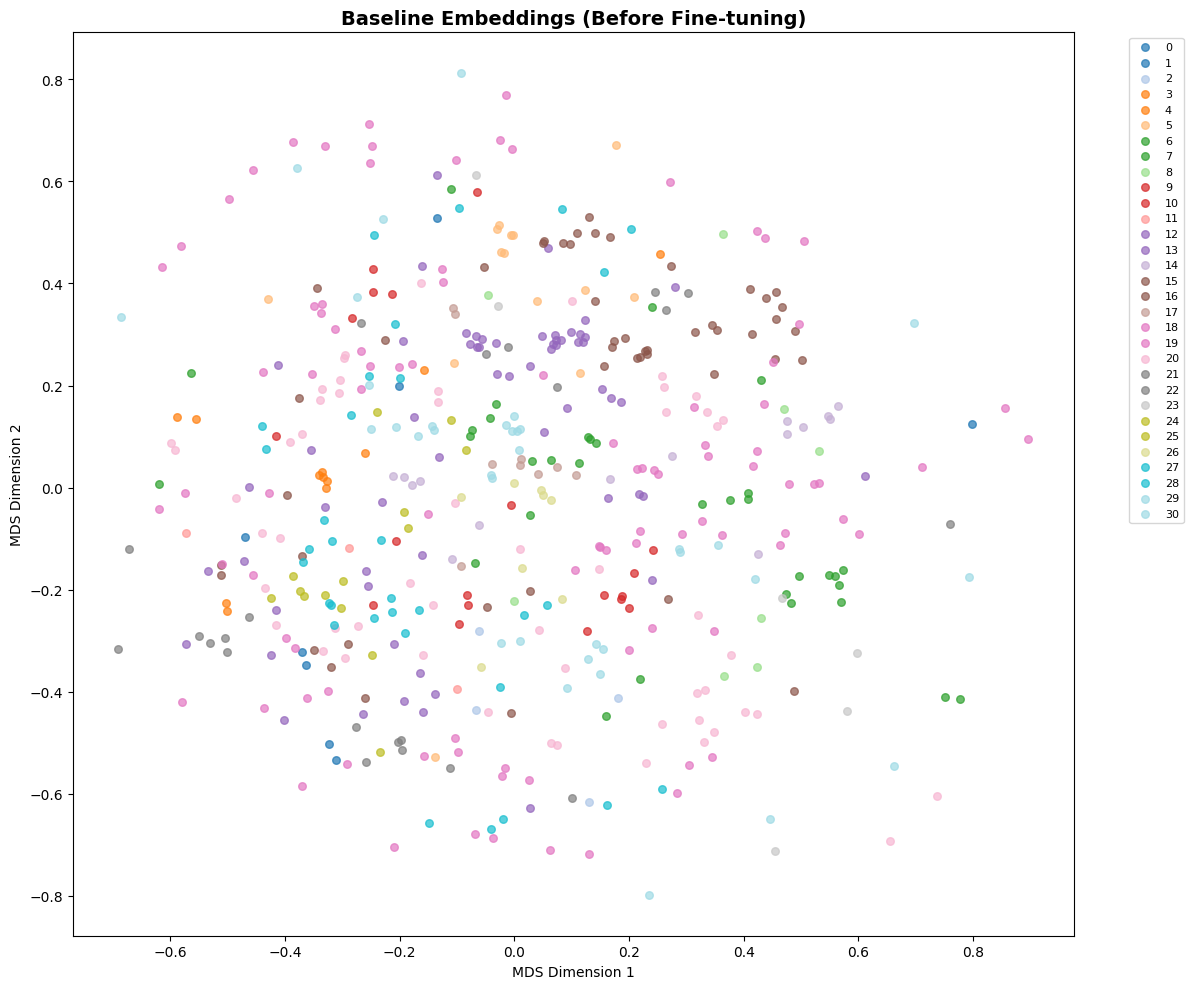

In [105]:
# Visualize DINO embeddings
fig = visualize_embeddings_mds(
    baseline_embeddings,
    labels,
    "Baseline Embeddings (Before Fine-tuning)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "baseline_embeddings_mds.png")
plt.show()

# Log to W&B
wandb.log({"baseline_embeddings_mds": wandb.Image(fig)})

In [106]:
baseline_emb_train_dataset = EmbeddingDataset(
    baseline_embeddings[train_mask],
    train_labels
)

baseline_emb_val_dataset = EmbeddingDataset(
    baseline_embeddings[~train_mask],
    val_labels
)

baseline_emb_train_loader = create_deterministic_training_dataloader(
    baseline_emb_train_dataset,
    batch_size=config["batch_size"],
)
baseline_emb_val_loader = DataLoader(
    baseline_emb_val_dataset,
    batch_size=config["batch_size"],
    num_workers=2,
    shuffle=False
)

In [107]:
# Create model
model = EmbeddingProjection(
    input_dim=dino_dim,
    hidden_dim=config["hidden_dim"],
    output_dim=config["embedding_dim"],
    dropout=config["dropout"],
).to(device)

model_num_params = sum(p.numel() for p in model.parameters())

print(f"Embedding Projection Model defined:")
print(f"  Total parameters: {model_num_params:,}")

Embedding Projection Model defined:
  Total parameters: 526,592


In [108]:
# Export initial model weights for reinitialization
initial_weights_path = CHECKPOINT_PATH / "model_initial_weights.pth"
torch.save(model.state_dict(), initial_weights_path)
print(f"Initial model weights saved to {initial_weights_path}")

Initial model weights saved to /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/checkpoints/loss/model_initial_weights.pth


In [109]:
table = [
    ["Loss Function", "Best val_mAP", "Best epoch"]
]

## Proxy Anchor Loss

In [134]:
class ProxyAnchorLoss(nn.Module):
    def __init__(self, num_classes, embedding_dim, margin=0.1, alpha=32):
        super().__init__()
        self.proxies = nn.Parameter(torch.randn(num_classes, embedding_dim))
        nn.init.kaiming_normal_(self.proxies, mode='fan_out')
        self.margin = margin
        self.alpha = alpha

    def forward(self, features, labels):
        features = F.normalize(features)
        proxies = F.normalize(self.proxies)

        sim = F.linear(features, proxies)  # cosine similarity

        pos_mask = F.one_hot(labels, num_classes=sim.size(1)).bool()
        neg_mask = ~pos_mask

        pos_exp = torch.exp(-self.alpha * (sim - self.margin)) * pos_mask
        neg_exp = torch.exp(self.alpha * (sim + self.margin)) * neg_mask

        pos_term = torch.log(1 + pos_exp.sum(dim=0)).sum()
        neg_term = torch.log(1 + neg_exp.sum(dim=0)).sum()

        loss = (pos_term + neg_term) / features.size(0)
        return loss
    
print(f"ProxyAnchor Model:")
print(f"  Embedding dim: {config['embedding_dim']}")
print(f"  Num classes: {num_classes}")
print(f"  ProxyAnchor margin: {config['proxyanchor_margin']}")
print(f"  ProxyAnchor alpha: {config['proxyanchor_alpha']}")

ProxyAnchor Model:
  Embedding dim: 256
  Num classes: 31
  ProxyAnchor margin: 0.1
  ProxyAnchor alpha: 32.0


In [135]:
# Setup training components
model.load_state_dict(torch.load(initial_weights_path))

criterion = ProxyAnchorLoss(
    num_classes=num_classes, 
    embedding_dim=config["embedding_dim"], 
    margin=config["proxyanchor_margin"], 
    alpha=config["proxyanchor_alpha"]
).to(device)

optimizer = torch.optim.AdamW(
    list(model.parameters()) + list(criterion.parameters()),
    lr=config["learning_rate"],
    weight_decay=config["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=5,
)

print("Training components initialized:")
print(f"  Loss: ProxyAnchorLoss")
print(f"  Optimizer: AdamW (lr={config['learning_rate']}, weight_decay={config['weight_decay']})")
print(f"  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)")

Training components initialized:
  Loss: ProxyAnchorLoss
  Optimizer: AdamW (lr=0.0001, weight_decay=0.0001)
  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)


In [136]:
# Training loop
set_seeds(config['seed'])
history, best_map, best_epoch = train(
    model, 
    baseline_emb_train_loader, 
    baseline_emb_val_loader, 
    criterion, 
    optimizer, 
    scheduler, 
    device,
    name="proxyanchor"
)

wandb.log({
    "final_val_mAP_proxyanchor": best_map,
    "best_epoch_proxyanchor": best_epoch,
    "total_epochs_proxyanchor": len(history['train_loss']),
})

table.append([
    "ProxyAnchor",
    best_map,
    best_epoch
])

All random seeds set to 51 for reproducibility
Starting training for 200 epochs...

Epoch 1/200


  Train Loss: 9.8629
  Val Loss:   8.0520
  Val mAP:    0.3457 | LR: 1.00e-04
  [New best model saved]

Epoch 2/200


  Train Loss: 9.0082
  Val Loss:   7.7356
  Val mAP:    0.3443 | LR: 1.00e-04
  No improvement. Patience: 1/10

Epoch 3/200


  Train Loss: 8.5761
  Val Loss:   7.5744
  Val mAP:    0.3476 | LR: 1.00e-04
  [New best model saved]

Epoch 4/200


  Train Loss: 8.2646
  Val Loss:   7.3789
  Val mAP:    0.3478 | LR: 1.00e-04
  [New best model saved]

Epoch 5/200


...

  Train Loss: 0.1639
  Val Loss:   0.7020
  Val mAP:    0.8741 | LR: 6.25e-06
  No improvement. Patience: 6/10

Epoch 162/200


  Train Loss: 0.1674
  Val Loss:   0.6916
  Val mAP:    0.8759 | LR: 6.25e-06
  No improvement. Patience: 7/10

Epoch 163/200


  Train Loss: 0.1691
  Val Loss:   0.7015
  Val mAP:    0.8762 | LR: 6.25e-06
  No improvement. Patience: 8/10

Epoch 164/200


  Train Loss: 0.1675
  Val Loss:   0.6960
  Val mAP:    0.8747 | LR: 6.25e-06
  No improvement. Patience: 9/10

Epoch 165/200


  Train Loss: 0.1596
  Val Loss:   0.7117
  Val mAP:    0.8749 | LR: 6.25e-06
  No improvement. Patience: 10/10

Early stopping triggered after 165 epochs

Training complete!
Best epoch: 155, Val mAP: 0.8770


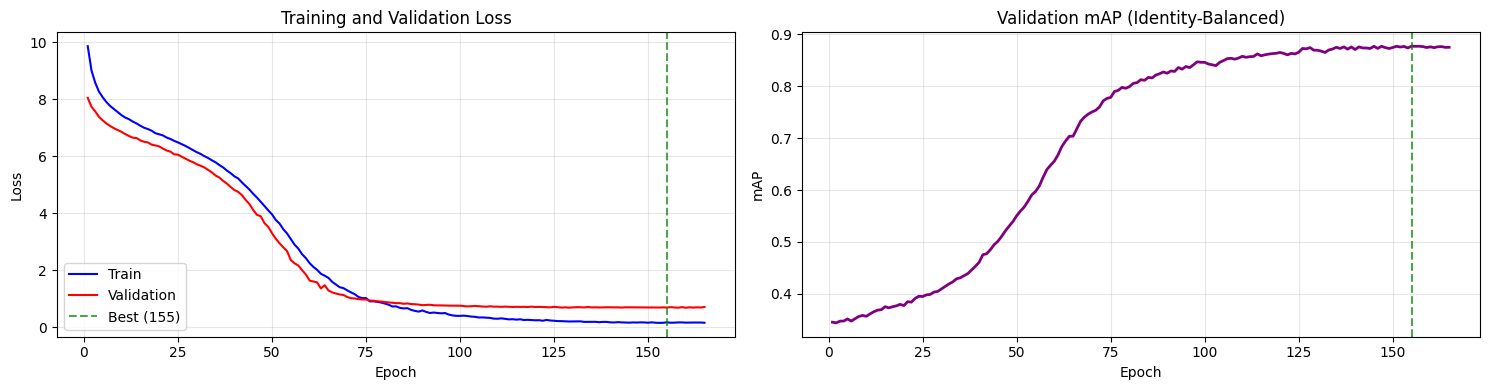

In [137]:
# Plot training curves
fig = plot_history(history, best_epoch)
plt.savefig(CHECKPOINT_PATH / 'training_curves_proxyanchor.png', dpi=150, bbox_inches='tight')
plt.show()

# Log to W&B
wandb.log({"training_curves_proxyanchor": wandb.Image(fig)})

In [138]:
# Load best model
checkpoint = torch.load(CHECKPOINT_PATH / "model_best_proxyanchor.pth", map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from epoch {CHECKPOINT_PATH}")
print(f"  Val Loss: {checkpoint['val_loss']:.4f}")
print(f"  Val mAP: {checkpoint['val_map']:.4f}")

Loaded best model from epoch /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/checkpoints/loss
  Val Loss: 0.6955
  Val mAP: 0.8770


In [139]:
# Extract fine-tuned embeddings for training data
model.eval()
with torch.no_grad():
    train_tensor = torch.FloatTensor(baseline_embeddings).to(device)
    finetuned_embeddings = model(train_tensor).cpu().numpy()
    finetuned_embeddings = finetuned_embeddings / np.linalg.norm(finetuned_embeddings, axis=1, keepdims=True)

print(f"Fine-tuned embeddings shape: {finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(finetuned_embeddings, axis=1).mean():.4f}")

Fine-tuned embeddings shape: (1895, 256)
Mean L2 norm: 1.0000


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


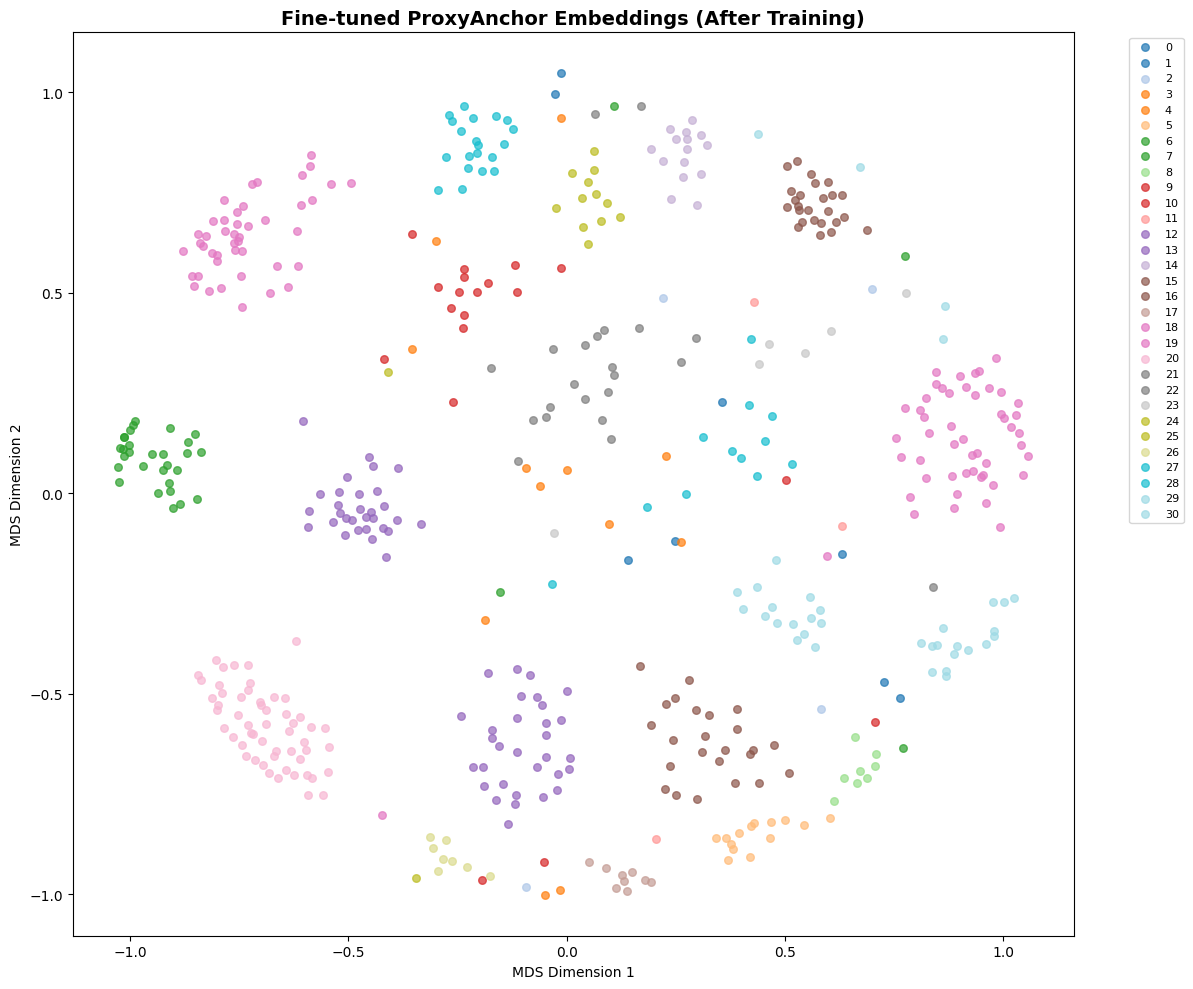

In [140]:
# Visualize fine-tuned embeddings
fig_finetuned = visualize_embeddings_mds(
    finetuned_embeddings,
    labels,
    "Fine-tuned ProxyAnchor Embeddings (After Training)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "proxyanchor_embeddings_mds_finetuned.png")
plt.show()

# Log to W&B
wandb.log({"finetuned_embeddings_mds_proxyanchor": wandb.Image(fig_finetuned)})

In [141]:
del optimizer, scheduler, history
torch.cuda.empty_cache()

## Proxy Anchor Loss + Center Loss

In [ ]:
class CenterLoss(nn.Module):
    def __init__(self, embedding_dim, num_classes):
        super().__init__()
        self.centers = nn.Parameter(torch.randn(num_classes, embedding_dim))

    def forward(self, features, labels):
        centers_batch = self.centers[labels]
        loss = ((features - centers_batch) ** 2).sum(dim=1).mean()
        return loss

print(f"Center Loss:")
print(f"  Embedding dim: {config['embedding_dim']}")
print(f"  Num classes: {num_classes}")


ProxyAnchor Model:
  Embedding dim: 256
  Num classes: 31
  ProxyAnchor margin: 0.1
  ProxyAnchor alpha: 32.0


In [ ]:
class CombinedLoss(nn.Module):
    def __init__(self, proxy_anchor_loss, center_loss, lambda_center=0.1):
        super().__init__()
        self.proxy_anchor_loss = proxy_anchor_loss
        self.center_loss = center_loss
        self.lambda_center = lambda_center

    def forward(self, features, labels):
        loss_proxy_anchor = self.proxy_anchor_loss(features, labels)
        loss_center = self.center_loss(features, labels)
        total_loss = loss_proxy_anchor + self.lambda_center * loss_center
        return total_loss
    
print(f"Combined Loss:")
print(f"  Components: ProxyAnchorLoss + CenterLoss")
print(f"  Lambda for Center Loss: {config['combined_lambda']}")

In [ ]:
# Setup training components

criterion = CombinedLoss(
    proxy_anchor_loss=ProxyAnchorLoss(
        num_classes=num_classes,
        embedding_dim=config["embedding_dim"],
        margin=config["proxyanchor_margin"],
        alpha=config["proxyanchor_alpha"]
    ),
    center_loss=CenterLoss(
        embedding_dim=config["embedding_dim"],
        num_classes=num_classes
    ),
    lambda_center=config["combined_lambda"]
).to(device)

optimizer = torch.optim.AdamW(
    list(model.parameters()) + list(criterion.parameters()),
    lr=config["learning_rate"],
    weight_decay=config["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=5,
)

print("Training components initialized:")
print(f"  Loss: ProxyAnchorLoss")
print(f"  Optimizer: AdamW (lr={config['learning_rate']}, weight_decay={config['weight_decay']})")
print(f"  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)")

Training components initialized:
  Loss: ProxyAnchorLoss
  Optimizer: AdamW (lr=0.0001, weight_decay=0.0001)
  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)


In [ ]:
# Training loop
set_seeds(config['seed'])
history, best_map, best_epoch = train(
    model, 
    baseline_emb_train_loader, 
    baseline_emb_val_loader, 
    criterion, 
    optimizer, 
    scheduler, 
    device,
    name="combined_proxyanchor_center"
)

wandb.log({
    "final_val_mAP_combined": best_map,
    "best_epoch_combined": best_epoch,
    "total_epochs_combined": len(history['train_loss']),
})

table.append([
    "Combined (ProxyAnchor + Center)",
    best_map,
    best_epoch
])

All random seeds set to 51 for reproducibility
Starting training for 200 epochs...

Epoch 1/200


  Train Loss: 9.8629
  Val Loss:   8.0520
  Val mAP:    0.3457 | LR: 1.00e-04
  [New best model saved]

Epoch 2/200


  Train Loss: 9.0082
  Val Loss:   7.7356
  Val mAP:    0.3443 | LR: 1.00e-04
  No improvement. Patience: 1/10

Epoch 3/200


  Train Loss: 8.5761
  Val Loss:   7.5744
  Val mAP:    0.3476 | LR: 1.00e-04
  [New best model saved]

Epoch 4/200


  Train Loss: 8.2646
  Val Loss:   7.3789
  Val mAP:    0.3478 | LR: 1.00e-04
  [New best model saved]

Epoch 5/200


...

  Train Loss: 0.1639
  Val Loss:   0.7020
  Val mAP:    0.8741 | LR: 6.25e-06
  No improvement. Patience: 6/10

Epoch 162/200


  Train Loss: 0.1674
  Val Loss:   0.6916
  Val mAP:    0.8759 | LR: 6.25e-06
  No improvement. Patience: 7/10

Epoch 163/200


  Train Loss: 0.1691
  Val Loss:   0.7015
  Val mAP:    0.8762 | LR: 6.25e-06
  No improvement. Patience: 8/10

Epoch 164/200


  Train Loss: 0.1675
  Val Loss:   0.6960
  Val mAP:    0.8747 | LR: 6.25e-06
  No improvement. Patience: 9/10

Epoch 165/200


  Train Loss: 0.1596
  Val Loss:   0.7117
  Val mAP:    0.8749 | LR: 6.25e-06
  No improvement. Patience: 10/10

Early stopping triggered after 165 epochs

Training complete!
Best epoch: 155, Val mAP: 0.8770


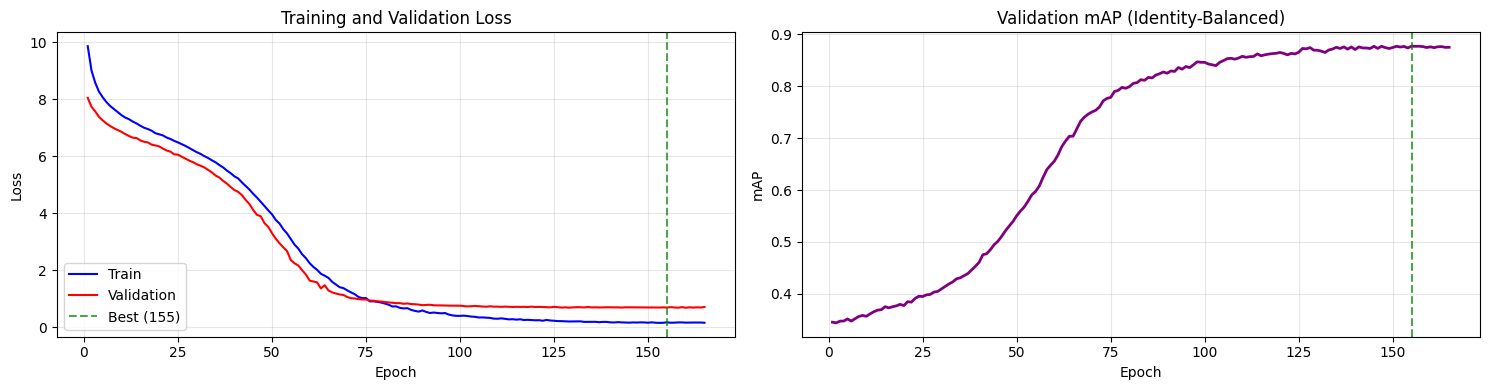

In [ ]:
# Plot training curves
fig = plot_history(history, best_epoch)
plt.savefig(CHECKPOINT_PATH / 'training_curves_combined.png', dpi=150, bbox_inches='tight')
plt.show()

# Log to W&B
wandb.log({"training_curves_combined": wandb.Image(fig)})

In [ ]:
# Load best model
checkpoint = torch.load(CHECKPOINT_PATH / "model_best_combined.pth", map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from epoch {CHECKPOINT_PATH}")
print(f"  Val Loss: {checkpoint['val_loss']:.4f}")
print(f"  Val mAP: {checkpoint['val_map']:.4f}")

Loaded best model from epoch /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/checkpoints/loss
  Val Loss: 0.6955
  Val mAP: 0.8770


In [ ]:
# Extract fine-tuned embeddings for training data
model.eval()
with torch.no_grad():
    train_tensor = torch.FloatTensor(baseline_embeddings).to(device)
    finetuned_embeddings = model(train_tensor).cpu().numpy()
    finetuned_embeddings = finetuned_embeddings / np.linalg.norm(finetuned_embeddings, axis=1, keepdims=True)

print(f"Fine-tuned embeddings shape: {finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(finetuned_embeddings, axis=1).mean():.4f}")

Fine-tuned embeddings shape: (1895, 256)
Mean L2 norm: 1.0000


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


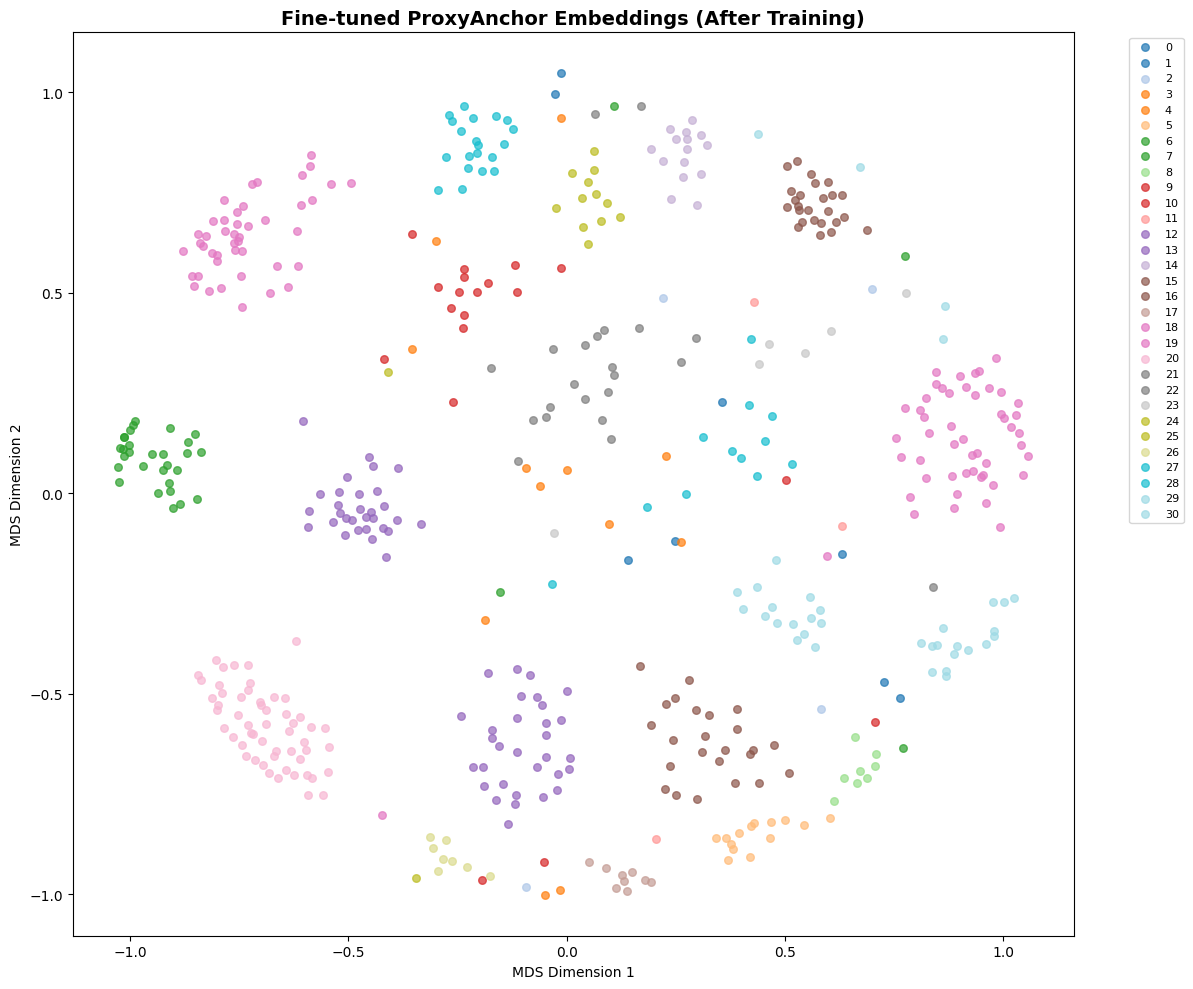

In [ ]:
# Visualize fine-tuned embeddings
fig_finetuned = visualize_embeddings_mds(
    finetuned_embeddings,
    labels,
    "Fine-tuned Combined Embeddings (After Training)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "combined_embeddings_mds_finetuned.png")
plt.show()

# Log to W&B
wandb.log({"finetuned_embeddings_mds_combined": wandb.Image(fig_finetuned)})

In [ ]:
del optimizer, scheduler, history
torch.cuda.empty_cache()

## Summary

In [166]:
rows = list(zip(*table)) # transpose for tabulate
print(tabulate(rows[1:], headers=rows[0], tablefmt="grid"))

+-----------------+-----------+-----------+--------------+---------------+--------------------+---------------+----------------------+
| Loss Function   |   ArcFace |   CosFace |   SphereFace |   ProxyAnchor |   SubCenterArcFace |   Center Loss |   Batch Hard Triplet |
+=================+===========+===========+==============+===============+====================+===============+======================+
| Best val_mAP    |  0.852964 |  0.857852 |     0.777434 |      0.877014 |           0.708112 |      0.860715 |             0.773713 |
+-----------------+-----------+-----------+--------------+---------------+--------------------+---------------+----------------------+
| Best epoch      | 87        | 80        |    57        |    155        |          64        |    138        |            98        |
+-----------------+-----------+-----------+--------------+---------------+--------------------+---------------+----------------------+
